# Deep learning models for arrhythmia detection and diagnosis

## Initialisation

In [1]:
# Imports
from os.path import join as osj
import pandas as pd
import numpy as np
import torch
import wfdb
import pywt
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.signal import resample
from imblearn.combine import SMOTETomek
from sklearn.datasets import make_classification
from collections import Counter

# Directory where the dataset is stored
dataset_directory = 'mit-bih-arrhythmia-database-1.0.0/'

# Initialise dictionaries and arrays to store data
lead1 = {}
lead2 = {}
signal_pairs = {}
annotations = {}
sample_size = 300
X = []
y = []

# Information about the labels
beat_annotations = [
    'N',  # Normal beat
    'L',  # Left bundle branch block beat
    'R',  # Right bundle branch block beat
    'B',  # Bundle branch block beat (unspecified)
    'e',  # Atrial escape beat
    'j',  # Nodal (junctional) escape beat

    'A',  # Atrial premature beat
    'a',  # Aberrated atrial premature beat
    'J',  # Nodal (junctional) premature beat
    'S',  # Supraventricular premature or ectopic beat (atrial or nodal)
    
    'V',  # Premature ventricular contraction
    'E',  # Ventricular escape beat
    'r',  # R-on-T premature ventricular contraction

    'F',  # Fusion of ventricular and normal beat
    
    'f',  # Fusion of paced and normal beat
    '/',  # Paced beat
    'Q',  # Unclassifiable beat
    '?',  # Beat not classified 
]

non_beat_annotations = [
    '[',  # Start of ventricular flutter/fibrillation
    '!',  # Ventricular flutter wave
    ']',  # End of ventricular flutter/fibrillation
    'x',  # Non-conducted P-wave (blocked APC)
    '(',  # Waveform onset
    ')',  # Waveform end
    'p',  # Peak of P-wave
    't',  # Peak of T-wave
    'u',  # Peak of U-wave
    '`',  # PQ junction
    "'",  # J-point
    '^',  # Non-captured pacemaker artifact
    '|',  # Isolated QRS-like artifact
    '~',  # Change in signal quality
    '+',  # Rhythm change
    's',  # ST segment change
    'T',  # T-wave change
    '*',  # Systole
    'D',  # Diastole
    '=',  # Measurement annotation
    '"',  # Comment annotation
    '@'   # Link to external data
]

# Label map designed to map MIT-BIH labels into the AAMI classes
AAMI_classes = {
    # N class
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0, 'B': 0,  
    # S class
    'A': 1, 'a': 1, 'J': 1, 'S': 1,                        
    # V class
    'V': 2, 'E': 2, 'r': 2,                                
    # F class
    'F': 3,                      
    # Q Class                          
    'f': 4, '/': 4, 'Q': 4, '?': 4  
}
    
# Create a Dataset object to be used later for training and testing
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32) 
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


## Data Preprocessing

### Preprocessing functions

In [2]:
def swt_denoise(signal_pair):
    """
    Denoises a pair of ECG signals using SWT with soft thresholding.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Pair of 1D signals.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Denoised pair.
    """
    def _denoise(signal):
        # Decompose
        max_level = pywt.swt_max_level(len(signal))
        wavelet = "bior3.1"
        coeffs = pywt.swt(signal, wavelet, level=max_level)

        
        detail_coeffs = np.array(coeffs[0][1])
        sigma = np.median(np.abs(detail_coeffs)) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(signal)))

        # Threshold coefficients
        new_coeffs = []
        for approx, detail in coeffs:
            detail = pywt.threshold(detail, threshold, mode='soft')
            new_coeffs.append((approx, detail))

        # Reconstruct and return
        return pywt.iswt(new_coeffs, wavelet)
    
    lead1, lead2 = signal_pair[:, 0], signal_pair[:, 1]
    return _denoise(lead1), _denoise(lead2)

def standardise(signal_pair):
    """
    Standardises a pair of ECG signals.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Pair of 1D signals.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Standardised signals.
    """
    def _standardise(signal):
        mean_val = np.mean(signal)
        std_val = np.std(signal)
        return (signal - mean_val) / std_val

    lead1, lead2 = signal_pair
    return _standardise(lead1), _standardise(lead2)
 
def segmentation_fixed_window(signal_pair, annotation, before=100, after=200):
    """
    Segments beats using a fixed window around each R-peak for both leads.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Tuple of 1D ECG signals (lead1, lead2).
        annotation (wfdb.Annotation): Annotation object with R-peaks.
        before (int): Number of samples before the R-peak.
        after (int): Number of samples after the R-peak.

    Returns:
        segments (List[np.ndarray]): List of 2x300 segments (2 leads).
        labels (List[str]): Corresponding beat labels.
    """
    lead1, lead2 = signal_pair
    r_peaks = annotation.sample
    r_labels = annotation.symbol

    segments = []
    labels = []

    for peak, label in zip(r_peaks, r_labels):
        start = peak - before
        end = peak + after

        # Ensure segment is within signal bounds
        if start < 0 or end > len(lead1):
            continue

        if label in beat_annotations:
            seg1 = lead1[start:end]
            seg2 = lead2[start:end]
            segment = np.stack([seg1, seg2], axis=0) # Shape: [2, window_length]
            segments.append(segment)
            labels.append(AAMI_classes[label])

    return segments, labels
             
def process_signal(signal_pair, annotation):
    """
    Takes an id and returns the X, y for that id.
    
    Parameters:
        id (int): The id of the record.
        
    Returns:
        tuple: A tuple containing the segments and labels.
    """
    denoised_pair = swt_denoise(signal_pair)
    normalised_pair = standardise(denoised_pair)
    segmented_pair, y = segmentation_fixed_window(normalised_pair, annotation)
        
    X = np.array(segmented_pair)  # Convert to numpy array
    
    X = torch.tensor(X, dtype=torch.float32)  

    y = torch.tensor(y, dtype=torch.long)
    
    return X, y

### Preprocessing for Signal Classifier

### Load data, apply processing to data and separate into train and testing

In [3]:
# Get an array of all ids
record_ids = pd.read_csv('mit-bih-arrhythmia-database-1.0.0/RECORDS', header=None).to_numpy().reshape(-1)

# Load the data
for id in record_ids:
    signal, info = wfdb.io.rdsamp(osj(dataset_directory, str(id)))
    annotation = wfdb.rdann(dataset_directory + str(id), "atr")
    X_i, y_i = process_signal(signal, annotation)
    X.append(X_i)
    y.append(y_i)

X = np.concatenate(X, axis=0)  # Shape: (total_samples, signal_length)
y = np.concatenate(y, axis=0)  # Shape: (total_samples,)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)

X shape: (109446, 2, 300), y shape: (109446,)
X_train shape: (65667, 2, 300) y_train shape: (65667,)


## Models

### Beat Classifier

In [4]:
class BeatClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(BeatClassifier, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # output shape: (batch_size, 128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),  # flatten (batch_size, 128, 1) -> (batch_size, 128)
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes) 
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, downsample=False):
        super(ResidualBlock1D, self).__init__()
        stride = 2 if downsample else 1
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.downsample = nn.Sequential()
        if downsample or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        identity = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)
    
class ResNet1D(nn.Module):
    def __init__(self):
        super(ResNet1D, self).__init__()
        self.layer1 = ResidualBlock1D(2, 32, downsample=True)  # First block
        self.layer2 = ResidualBlock1D(32, 64, downsample=True)  # Second block
        self.layer3 = ResidualBlock1D(64, 128, downsample=True)  # Third block
        self.pool = nn.AdaptiveAvgPool1d(1)  # Global average pooling

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        return x

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = torch.mean(x, dim=-1)
        max_pool, _ = torch.max(x, dim=-1)
        channel_attention = self.sigmoid(self.fc2(self.fc1(avg_pool)) + self.fc2(self.fc1(max_pool)))
        return x * channel_attention.unsqueeze(-1)

class RATNet(nn.Module):
    def __init__(self, num_classes=5):
        super(RATNet, self).__init__()
        self.backbone = ResNet1D()
        self.attention = ChannelAttention(128)  # Adjust based on the ResNet output channels
        self.transformer = nn.Transformer(d_model=128, nhead=4, num_encoder_layers=2)
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)  # Output: num_classes (e.g., 5 for 5 ECG classes)
        )

    def forward(self, x):
        x = self.backbone(x)  # Pass through ResNet
        x = self.attention(x)  # Apply Channel Attention
        # x = x.squeeze(-1).unsqueeze(0)  # [1, B, 128] for Transformer
        # x = self.transformer(x,x)  # Apply Transformer
        # x = x.mean(dim=0)
        x = self.flatten(x)  # Flatten the output
        x = self.classifier(x)  # Classify
        return x



### Signal Classifier

## Training

### Training Parameters

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

epochs = 30
batch_size = 32
learning_rate = 0.001

train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)
validation_dataset = ECGDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# Compute class weights
counts = np.bincount(y_train)        
weights = 1.0 / counts.astype(float)
weights /= np.sum(weights)  # Normalize weights to sum to 1   

class_weights = torch.from_numpy(weights).float().to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

beat_classifier = RATNet().to(device)
loss_function = nn.CrossEntropyLoss()
optimiser = optim.Adam(beat_classifier.parameters(), lr=learning_rate)

cuda


c:\Users\elija\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


### Training and Testing loops

In [7]:
def train_beat_classifier(model, criterion, optimiser, train_dataloader, val_dataloader, epochs=10, device="cpu"):
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_loss, correct, total = 0, 0, 0

        for inputs, labels in train_dataloader:
            inputs = inputs.to(device) 
            labels = labels.to(device)

            optimiser.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()

            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = correct / total
        
        # Validation phase
        model.eval()  # Set the model to evaluation mode
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():  # No gradients are computed during validation
            for inputs, labels in val_dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")


def train_signal_classifier(model, criterion, optimizer):
    pass

def test_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)


    print(f"Test Accuracy:     {acc*100:.4f}") # average=None? 
    print(f"Test Precision:    {precision*100:.4f}")
    print(f"Test Recall:       {recall*100:.4f}")
    print(f"Test F1 Score:     {f1*100:.4f}")

    print("Confusion Matrix (Test):")
    cm_test = confusion_matrix(all_labels, all_preds)
    cm_test_disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1, 2, 3, 4])
    cm_test_disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix - Test")
    plt.show()

## Evaluation

In [ ]:
train_beat_classifier(beat_classifier, loss_function, optimiser, train_loader, validation_loader, epochs=epochs, device=device)

Epoch 1/30 - Train Loss: 0.0256 - Train Acc: 0.9918 - Val Loss: 0.0471 - Val Acc: 0.9890
Epoch 2/30 - Train Loss: 0.0255 - Train Acc: 0.9920 - Val Loss: 0.0412 - Val Acc: 0.9895
Epoch 3/30 - Train Loss: 0.0246 - Train Acc: 0.9921 - Val Loss: 0.0496 - Val Acc: 0.9888
Epoch 4/30 - Train Loss: 0.0236 - Train Acc: 0.9929 - Val Loss: 0.0448 - Val Acc: 0.9888
Epoch 5/30 - Train Loss: 0.0224 - Train Acc: 0.9928 - Val Loss: 0.0425 - Val Acc: 0.9903
Epoch 6/30 - Train Loss: 0.0227 - Train Acc: 0.9930 - Val Loss: 0.0437 - Val Acc: 0.9895
Epoch 7/30 - Train Loss: 0.0220 - Train Acc: 0.9933 - Val Loss: 0.0467 - Val Acc: 0.9896


Test Accuracy:     98.9584
Test Precision:    96.9411
Test Recall:       90.6645
Test F1 Score:     93.4752
Confusion Matrix (Test):


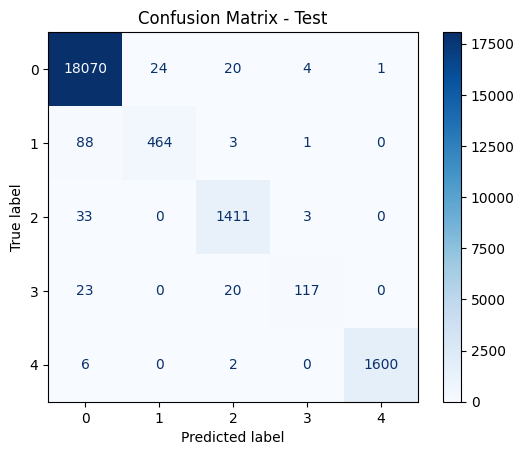

In [9]:
test_model(beat_classifier, test_loader)